# Analysis test - modified correlation with the library
Calculate best correlation match with (arithmetic modification) of Gabor filter library decomposed visual stimulation. 

Puts output in dedicated folder.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
import json
import pandas as pd
import pickle

from wavelet_utils_vSpeed import loadFilterParamDict_vS, makeFilterParamDict_vS, saveFilterParamDict_vS, filename_fromFilterParam, compute_and_save_dwt_vS, get_filter_from_params
from analysis_utils import compute_respcorr_split_half, FeatureSearch_correlation_batched, fit_sine1x, sine1x, dwt_amp_phase_torch_batched, gaussian_filter1d_torch_axis0_chunked, restore_fit_quadratic, fit_quadratic, downscale_binary_video

In [2]:
##jobFolder_str=r"GBM11\g11_0409_zebra"
##jobFolder_str=r"GBM11\g11_0409_zebra5"
##jobFolder_str=r"GBM11\g11_0415_zebra5"
##jobFolder_str=r"GBM11\g11_0423_zebra6"
jobFolder_str=r"GBM11\g11_0508_full"
#jobFolder_str=r"GBM11\g11_0603_r2_z225"
#jobFolder_str=r"GBM11\g11_0603_r2_z185"
#jobFolder_str=r"GBM11\g11_0603_r2_z265"
#jobFolder_str=r"GBM11\g11_0605_r2_z225"
#jobFolder_str=r"GBM11\g11_0605_r2_z225LS"
#jobFolder_str=r"GBM11\g11_0605_r2_z225US"
jobFolder_str=r"GBM11\g11_0619_full"
jobFolder_str=r"GBM11\g11_0714_fov"
jobFolder_str=r"GBM11\g11_0717_fov"
jobFolder_str=r"GBM11\g11_0717_fast"
jobFolder_str=r"GBM11\g11_0730_zebraO"

#jobFolder_str=r"GBM15\g15_0408_zebra"
#jobFolder_str=r"GBM15\g15_0422_zebra3"

In [3]:
spks_path = "D:\\SynologyDriveSyncedDATA\\PROCESSED\\GBM\\" +  jobFolder_str + "\\ZEBRA_ANALYSIS\\resps_all.npy"
#spks_path = "D:\\SynologyDriveSyncedDATA\\PROCESSED\\GBM\\" +  jobFolder_str + "\\ZEBRA_ANALYSIS\\resps_all1.npy"
#spks_path = "D:\\SynologyDriveSyncedDATA\\PROCESSED\\GBM\\" +  jobFolder_str + "\\ZEBRA_ANALYSIS\\resps_all2.npy"

if Path(spks_path).exists():   print(spks_path)
else: print(f"File not found: {spks_path}")


D:\SynologyDriveSyncedDATA\PROCESSED\GBM\GBM11\g11_0730_zebraO\ZEBRA_ANALYSIS\resps_all.npy


In [4]:
full_screen_coverage = [-15, 105, -17.5, 50] # [az_left, az_right, el_bottom, el_top] full screen position in visual degrees
visual_coverage = [-15, 105, -17.5, 50] # [az_left, az_right, el_bottom, el_top] screen coverage in visual degrees (seen by the animal)

screen_x = 120 # horizontal screen size in pixels for the Gabor filter generation and movie analysis

nx = 20 # number of Gabor filters in the horizontal direction (azimuth) (y will be generated)
        # 40 is a good number. Use 5 for testing to make it fast

n_thetas = 16 # number of angles to generate
theta_max = np.pi*1

size_min = 5 # minimum size in visual degrees
size_max = 25 # maximum size in visual degrees
n_sizes = 7   # number of sizes to generate

freq_min = .025 # minimum frequency in cycles per visual degree
freq_max = .15 # maximum frequency in cycles per visual degree
n_freqs = 7  # number of frequencies to generate

n_phases = 2  # number of phases to generate
phase_max = np.pi*1 # maximum phase to generate


In [5]:
# Video to analyze
temppath = r'D:\SynologyDriveSyncedDATA\PROCESSED\Waven'
#resampled_video_path = Path(temppath) / r"zebra_s0_d420.0_fps59.94_RESAMPLED30fps.mp4"
#resampled_video_path = Path(temppath) / r"zebra_s1_d420.0_fps59.94_RESAMPLED30fps.mp4"

resampled_video_path = Path(temppath) / r"zebra_s0_d360.0_fps144.00_RESAMPLED30fps.mp4"
#resampled_video_path = Path(temppath) / r"zebra_s1_d360.0_fps144.00_RESAMPLED30fps.mp4"

In [6]:
#calculations
az_left, az_right, el_bottom, el_top = visual_coverage

screen_y = int(screen_x * (el_top - el_bottom) / (az_right - az_left))
ny = int(nx * (el_top - el_bottom) / (az_right - az_left))

# centers in visual degrees
xs = np.linspace(az_left, az_right, nx, endpoint=False)+(az_right - az_left) / (2*nx)
ys = np.linspace(el_bottom, el_top, ny, endpoint=False)+(el_top - el_bottom) / (2*ny)

angles= np.linspace(0, theta_max, n_thetas, endpoint=False)
sizes = np.logspace(np.log10(size_min), np.log10(size_max), n_sizes)
freqs = np.logspace(np.log10(freq_min), np.log10(freq_max), n_freqs)
phases = np.linspace(0,  phase_max, n_phases, endpoint=False)

print(f"Screen size: {screen_x}x{screen_y} pixels")
print(f"Full screen coverage: {full_screen_coverage} degrees")
print(f"Visual coverage: {visual_coverage} degrees")
print(f"Center positions (x_deg): {np.round(xs, 1)} degrees")
print(f"Center positions (y_deg): {np.round(ys, 1)} degrees")
print(f"Angles (°): {np.round(np.rad2deg(angles), 1)}")
print(f"Sizes (degrees): [",  ", ".join(f"{x:.2f}" for x in sizes) + " ]") 
print(f"Frequencies (cycles/degree): [",  ", ".join(f"{x:.3f}" for x in freqs) + " ]") 
print(f"Phases (°): {np.rad2deg(phases)}")

Screen size: 120x67 pixels
Full screen coverage: [-15, 105, -17.5, 50] degrees
Visual coverage: [-15, 105, -17.5, 50] degrees
Center positions (x_deg): [-12.  -6.   0.   6.  12.  18.  24.  30.  36.  42.  48.  54.  60.  66.
  72.  78.  84.  90.  96. 102.] degrees
Center positions (y_deg): [-14.4  -8.3  -2.2   4.   10.1  16.2  22.4  28.5  34.7  40.8  46.9] degrees
Angles (°): [  0.   11.2  22.5  33.8  45.   56.2  67.5  78.8  90.  101.2 112.5 123.7
 135.  146.2 157.5 168.8]
Sizes (degrees): [ 5.00, 6.54, 8.55, 11.18, 14.62, 19.12, 25.00 ]
Frequencies (cycles/degree): [ 0.025, 0.034, 0.045, 0.061, 0.083, 0.111, 0.150 ]
Phases (°): [ 0. 90.]


In [7]:
total_n=len(sizes)*len(angles)*len(freqs)*len(phases)*len(xs)*len(ys)
print(f"Total number of Gabor filters to generate: {total_n}")

Total number of Gabor filters to generate: 344960


In [8]:
gabor_step=(az_right-az_left)/nx 
print(f"Control: Gabor placement step in visual degrees (x): {gabor_step:.1f}, vs size_min: {size_min:.1f} degrees. {'OK' if (gabor_step < size_min) else 'WARNING!'}")
gabor_step=(el_top-el_bottom)/ny
print(f"Control: Gabor placement step in visual degrees (y): {gabor_step:.1f}, vs size_min: {size_min:.1f} degrees. {'OK' if (gabor_step < size_min) else 'WARNING!'}")
visual_step_x=(az_right-az_left)/screen_x
print(f"Control: Gabor resolution in visual degrees (x): {visual_step_x:.1f}, vs 1/freq_max: {1/freq_max:.1f} degrees. {'OK' if (visual_step_x < 1/freq_max/4) else 'WARNING!'}")
visual_step_y=(el_top-el_bottom)/screen_y
print(f"Control: Gabor resolution in visual degrees (y): {visual_step_y:.1f}, vs 1/freq_max: {1/freq_max:.1f} degrees. {'OK' if (visual_step_y < 1/freq_max/4) else 'WARNING!'}")

wavelet_params=makeFilterParamDict_vS(screen_x, screen_y,  visual_coverage, full_screen_coverage, xs, ys, angles, sizes, freqs,  phases)


Control: Gabor placement step in visual degrees (x): 6.0, vs size_min: 5.0 degrees. WARNING!
Control: Gabor placement step in visual degrees (y): 6.1, vs size_min: 5.0 degrees. WARNING!
Control: Gabor resolution in visual degrees (x): 1.0, vs 1/freq_max: 6.7 degrees. OK
Control: Gabor resolution in visual degrees (y): 1.0, vs 1/freq_max: 6.7 degrees. OK


In [9]:
working_dir = Path(spks_path).parent
print(f"Working directory: {working_dir}")

Working directory: D:\SynologyDriveSyncedDATA\PROCESSED\GBM\GBM11\g11_0730_zebraO\ZEBRA_ANALYSIS


In [10]:
#load spike data
spks=np.load(spks_path)
print(f"spks shape: {spks.shape} (n_trials, n_timepoints, n_neurons)")
n_trials=spks.shape[0]
n_timepoints=spks.shape[1]
n_neurons=spks.shape[2]

## converts neuron position in microns
#neuron_pos=np.load(working_dir / 'component_centers.npy')
#neuron_pos=correctNeuronPos(neuron_pos, resolution)
#print(f"neuron_pos shape: {neuron_pos.shape}")

spks shape: (3, 10800, 2163) (n_trials, n_timepoints, n_neurons)


In [11]:
#loading cell database from previous step and metadata
input_pickle_path= working_dir / "cells_caiman.cellDB_pickle"
if input_pickle_path.exists():
    print(f"Loading cell database from {input_pickle_path}")
    objects = []

    with open(input_pickle_path, "rb") as f:
        while True:
            try:
                objects.append(pickle.load(f))
            except EOFError:
                break

    print(f"Pickle contains {len(objects)} serialized object(s)")
    for i, obj in enumerate(objects, start=1):
        print(f"Object {i}: {type(obj).__name__}")

    if (
        len(objects) == 2
        and isinstance(objects[0], pd.DataFrame)
        and isinstance(objects[1], dict)
    ):
        df_cells, metadata = objects
        print("Valid: DataFrame followed by metadata dictionary")
    else:
        print("Unexpected pickle structure")
    print(f"Loaded cell database from {input_pickle_path}")
else:
    df_cells = pd.DataFrame()
    for _idx in range(n_neurons): 
            record={}
            record['cell_id'] = _idx
            record['SeriesID'] = 'unknown'
            df_cells = pd.concat([df_cells, pd.DataFrame([record])], ignore_index=True)
    metadata = {}
    metadata["target_fps"] = 30
    print(f"No cell database found at {input_pickle_path}. Created empty cell database with {n_neurons} cells. Assuming target_fps=30.")

df_cells = df_cells.set_index("cell_id", drop=False)
target_fps = metadata["target_fps"]

metadata["spks_path"] = spks_path
metadata["wavelet_params"] = wavelet_params

Loading cell database from D:\SynologyDriveSyncedDATA\PROCESSED\GBM\GBM11\g11_0730_zebraO\ZEBRA_ANALYSIS\cells_caiman.cellDB_pickle


C:\Users\KatonaGergely\AppData\Local\Temp\ipykernel_49552\3906544591.py:10: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  objects.append(pickle.load(f))


Pickle contains 2 serialized object(s)
Object 1: DataFrame
Object 2: dict
Valid: DataFrame followed by metadata dictionary
Loaded cell database from D:\SynologyDriveSyncedDATA\PROCESSED\GBM\GBM11\g11_0730_zebraO\ZEBRA_ANALYSIS\cells_caiman.cellDB_pickle


In [12]:
#restrict df_cells and spks to accepted cells where  df["Accepted"] == "TRUE"
accepted_mask=df_cells["Accepted"] == True
if False:
    df_cells=df_cells[accepted_mask]
    spks=spks[:, :, accepted_mask]
    print(f"spks shape: {spks.shape} (n_trials, n_timepoints, n_accepted_cells)")
    n_neurons=spks.shape[2]
    print(f"n_neurons: {n_neurons}")

In [13]:
# Video to analyze: Downsampling video if needed
#downsampled_video_path=downscale_binary_video(resampled_video_path, full_screen_coverage, visual_coverage, screen_x, screen_y, force=False)
downsampled_video_path=downscale_binary_video(resampled_video_path, full_screen_coverage, visual_coverage, screen_x, screen_y, fps=target_fps, force=False)
metadata["resampled_video_file"] = str(resampled_video_path)
metadata["downsampled_video_path"] = str(downsampled_video_path)

_, paramname = filename_fromFilterParam(wavelet_params)
paramspath = downsampled_video_path.parent / paramname
saveFilterParamDict_vS(wavelet_params, paramspath)
print(f"Saved Gabor filter parameters to {paramspath}")


Generating cropped and downsampled binary video...
Output file D:\SynologyDriveSyncedDATA\PROCESSED\Waven\zebra_s0_d360.0_fps144.00_RESAMPLED30fps_scaled120x67.npy already exists. Skipping generation.
Saved Gabor filter parameters to D:\SynologyDriveSyncedDATA\PROCESSED\Waven\gaborLibrary_20_11_16_7_7_2.e5f712b8.json


## Calculate DWT if not already done

In [14]:
dwt_path=compute_and_save_dwt_vS(downsampled_video_path, wavelet_params,   device='cuda', force=False)
if Path(dwt_path).exists():   print(dwt_path)
else: print(f"File not found: {dwt_path}")

Loaded downsampled video data from D:\SynologyDriveSyncedDATA\PROCESSED\Waven\zebra_s0_d360.0_fps144.00_RESAMPLED30fps_scaled120x67.npy with shape (10800, 120, 67) and dtype bool
||Constructing: zebra_s0_d360.0_fps144.00_RESAMPLED30fps_scaled120x67_lib20_11_16_7_7_2.e5f712b8dwt.npy 
Wavelet transform file D:\SynologyDriveSyncedDATA\PROCESSED\Waven\zebra_s0_d360.0_fps144.00_RESAMPLED30fps_scaled120x67_lib20_11_16_7_7_2.e5f712b8dwt.npy already exists. Skipping computation.
D:\SynologyDriveSyncedDATA\PROCESSED\Waven\zebra_s0_d360.0_fps144.00_RESAMPLED30fps_scaled120x67_lib20_11_16_7_7_2.e5f712b8dwt.npy


In [15]:
xs, ys, angles, sizes, freqs,   phases, visual_coverage, full_screen_coverage,  screen_x, screen_y = loadFilterParamDict_vS(paramspath)

In [16]:
# Gauss averaging along dimension 1 with set FWHM (target_fps=30)
from scipy.ndimage import gaussian_filter1d
target_fps = metadata["target_fps"]

average_FWHM_sec = 0.1 #sec
average_FWHM_samples = int(np.round(target_fps * average_FWHM_sec))

shift_samples = 1 # shift by 1 sample to account for the calcium bindingdelay of the dye
print(f"Defining average_FWHM_samples={average_FWHM_samples} and shift_samples={shift_samples}")

if average_FWHM_samples > 0:
    spks = gaussian_filter1d(spks, sigma=average_FWHM_samples / 2.355,  axis=1)
if shift_samples != 0:
    spks = np.roll(spks, -shift_samples, axis=1)
print(f"spks shape: {spks.shape} (n_trials, n_timepoints, n_neurons), smoothed by {average_FWHM_samples} samples, shifted forward by {shift_samples} samples")

mean_spks = np.mean(spks[:, :, :], axis=0)

metadata["shift_samples"] = shift_samples

Defining average_FWHM_samples=3 and shift_samples=1
spks shape: (3, 10800, 2163) (n_trials, n_timepoints, n_neurons), smoothed by 3 samples, shifted forward by 1 samples


## Correlate neural data with decomposed stimulus

In [17]:
# load dwt
dwt = np.load(dwt_path)
print(f"dwt shape: {dwt.shape}")

dwt shape: (10800, 20, 11, 16, 7, 7, 2)


In [18]:
# modify dwt
mode=4
 
if mode==0: # no modification
    comment='orig'
elif mode==1: # restrict dwt to >0
    comment='Gt0'
    dwt[dwt < 0] = 0
elif mode==2: # take absolute value
    comment='abs'
    dwt=np.abs(dwt)  
elif mode==4: # complex
    #if len(phases)!=2:
    #    raise ValueError("For complex representation, n_phases must be 2.")
    comment='complex'
    print(f"phases: {phases}")
    #Calculating  amplitude and phase from the two phase DWT  
    dwt =dwt_amp_phase_torch_batched(dwt, phases)  # drops last feature dimension: phase
    
feature_dim_number=len(dwt.shape)-1

if average_FWHM_samples > 0:
    #dwt_mod = gaussian_filter1d(dwt_mod, sigma=average_FWHM_samples / 2.355,  axis=0)
    dwt = gaussian_filter1d_torch_axis0_chunked(dwt, average_FWHM_samples / 2.355)
    
print(f"Using dwt mode: {comment}, feature dimension number: {feature_dim_number}")

metadata["dwt_mode"] = comment
metadata["feature_dim_number"] = feature_dim_number

phases: [0.         1.57079633]
    Torch using: cuda, GPU index: 0, GPU name: NVIDIA GeForce RTX 5070 Ti


Calculating DWT amplitude and phase: 100%|██████████| 227391/227391 [00:34<00:00, 6569.61it/s]


| Torch (cuda:0) tensor memory usage:
| ------------------------------------------------------------
| batch               :     0.04 MB  | shape=(5120, 2)  dtype=torch.float32
| real                :     0.02 MB  | shape=(5120,)  dtype=torch.float32
| imag                :     0.02 MB  | shape=(5120,)  dtype=torch.float32
| amp                 :     0.02 MB  | shape=(5120,)  dtype=torch.float32
| ------------------------------------------------------------
| TENSORS:     0.10 MB (  0.0%) | RESERVED:     2.00 MB (  0.0%) | TOTAL GPU: 16302.56 MB  
    Torch using: cuda, GPU index: 0, GPU name: NVIDIA GeForce RTX 5070 Ti


Gaussian smoothing: 100%|██████████| 9/9 [00:12<00:00,  1.40s/it]


Using dwt mode: complex, feature dimension number: 5


## Splitting data

In [19]:
#defining train and test data parts
train_test=True #whether to split data in train and test set, if False use all data for training and no test evaluation
train_split=0.85 #split ratio in time if train_test 7min -> 6+1 min
# train_split=0.57 #split ratio in time if train_test 7min -> 4+3 min
#train_split=0.43 #split ratio in time if train_test 7min -> 3+4 min
#train_split=0.28 #split ratio in time if train_test 7min -> 2+5 min

if train_test:
    train_split_index=int(n_timepoints*train_split)
else:
    train_split_index=n_timepoints

print(f"Train split at {train_split_index/n_timepoints*100:.1f}% of timepoints, test split at {((1-train_split_index/n_timepoints)*100):.1f}% of timepoints")

metadata["train_split"] = train_split
metadata["train_split_index"] = train_split_index

Train split at 85.0% of timepoints, test split at 15.0% of timepoints


In [20]:
## runs correlation analysis

rfs = FeatureSearch_correlation_batched(dwt[:train_split_index], mean_spks[:train_split_index])


    stim_flat shape: (9180, 172480) (n_timepoints=9180, n_features=172480)
    resp shape: (9180, 2163) (n_timepoints=9180, n_neurons=2163)
    Torch using: cuda, GPU index: 0, GPU name: NVIDIA GeForce RTX 5070 Ti


Pearson RF feature batches: 100%|██████████| 18/18 [00:05<00:00,  3.19it/s]


| Torch (cuda:0) tensor memory usage:
| ------------------------------------------------------------
| R                   :    75.75 MB  | shape=(2163, 9180)  dtype=torch.float32
| S_chunk             :    86.85 MB  | shape=(2480, 9180)  dtype=torch.float32
| rfs_chunk           :    20.46 MB  | shape=(2163, 2480)  dtype=torch.float32
| ------------------------------------------------------------
| TENSORS:   183.06 MB (  1.1%) | RESERVED:  1562.00 MB (  9.6%) | TOTAL GPU: 16302.56 MB  
    output shape: (2163, 20, 11, 16, 7, 7) (neurons=2163, feature_dims=(20, 11, 16, 7, 7))


## Analyze results

In [21]:
output_folder = working_dir / (paramname.replace('.json', '')+f"_{comment}")
output_folder.mkdir(exist_ok=True)
saveFilterParamDict_vS(wavelet_params, output_folder / paramname)  # save a copy in the output folder 
print(f"Saved Gabor filter parameters to {output_folder}")

Saved Gabor filter parameters to D:\SynologyDriveSyncedDATA\PROCESSED\GBM\GBM11\g11_0730_zebraO\ZEBRA_ANALYSIS\gaborLibrary_20_11_16_7_7_2.e5f712b8_complex


In [22]:
respcorr = compute_respcorr_split_half(spks)

# top 3 most repeatable neurons
top_neurons = np.argsort(respcorr)[-3:]
print(f"Top 3 most repeatable neurons: {top_neurons}")

Computing split-half correlation per neuron: 100%|██████████| 2163/2163 [00:01<00:00, 1822.18it/s]

Top 3 most repeatable neurons: [1005 1700  873]


In [23]:
# fit tuning curves: Angle: sine, others: quadratic
tuning_angles_fit=[]
for _idx in range(n_neurons):
    myrfs = rfs[_idx]
    max_idx = np.unravel_index(np.argmax(myrfs), myrfs.shape)
    max_idx = tuple(int(i) for i in max_idx)
    tuning_curve_raw = myrfs[max_idx[0], max_idx[1], :, *max_idx[3:feature_dim_number]]
    
    sin_params = fit_sine1x(angles, tuning_curve_raw)
    tuning_angles_fit.append(sin_params)
    
# fit quadratic to other features (xs, ys, sizes, freqs, drifts) 
tuning_xs_fit=[]
tuning_ys_fit=[]
tuning_sizes_fit=[]
tuning_freqs_fit=[]

for _idx in range(n_neurons):
    myrfs = rfs[_idx]
    max_idx = np.unravel_index(np.argmax(myrfs), myrfs.shape)
    max_idx = tuple(int(i) for i in max_idx)
    tuning_xs_raw = myrfs[:, *max_idx[1:feature_dim_number]]
    best, params = fit_quadratic(xs, tuning_xs_raw)
    tuning_xs_fit.append((best, params))

    tuning_ys_raw = myrfs[max_idx[0], :, *max_idx[2:feature_dim_number]]
    best, params = fit_quadratic(ys, tuning_ys_raw)
    tuning_ys_fit.append((best, params))

    tuning_sizes_raw = myrfs[max_idx[0], max_idx[1], max_idx[2], :, *max_idx[4:feature_dim_number]]
    best, params = fit_quadratic(sizes, tuning_sizes_raw)
    tuning_sizes_fit.append((best, params))

    tuning_freqs_raw = myrfs[max_idx[0], max_idx[1], max_idx[2], max_idx[3], :, *max_idx[5:feature_dim_number]]
    best, params = fit_quadratic(freqs, tuning_freqs_raw)
    tuning_freqs_fit.append((best, params))
    

In [24]:
#play: # find absolut maximum RF value across all neurons and features
max_idx = np.unravel_index(np.argmax(rfs), rfs.shape)
max_idx = tuple(int(i) for i in max_idx)
max_value = rfs[max_idx]
print(f"max RF value: {max_value} at index {max_idx}")

max RF value: 0.6112763285636902 at index (732, 10, 4, 12, 4, 5)


In [25]:
#play: # find maximum RF value for a specific neuron
my_neuron = 456
# my_neuron = 1813 

myrfs = rfs[my_neuron]
max_idx = np.unravel_index(np.argmax(myrfs), myrfs.shape)
max_idx = tuple(int(i) for i in max_idx)
max_value = myrfs[max_idx]
print(f"Neuron {my_neuron} max RF value: {max_value:.3f} at index {max_idx}, respcorr: {respcorr[my_neuron]:.3f}")

Neuron 456 max RF value: 0.309 at index (5, 3, 7, 5, 2), respcorr: 0.114


## Calculate train and test performance for each neuron

In [26]:
# find maximum RF value for each neuron (train performance) and compute test correlation
r_train = np.zeros(n_neurons) # correlation of train data at the best RF prediction
r_test = np.zeros(n_neurons) # correlation of test data at the best RF prediction
max_idxs = np.zeros((n_neurons, len(rfs.shape)-1), dtype=int) # store the RF index of the best RF for each neuron

for i in range(n_neurons):
    myrfs = rfs[i]
    max_idx = np.unravel_index(np.argmax(myrfs), myrfs.shape)
    max_idx = tuple(int(ij) for ij in max_idx)
    max_idxs[i] = max_idx
    r_train[i] = myrfs[max_idx] # this equals to np.corrcoef(mean_spks[:train_split_index, i], dwt_squared[:train_split_index, *max_idx])[0, 1]
    r_test[i] = np.corrcoef(mean_spks[train_split_index:, i], dwt[train_split_index:, *max_idx])[0, 1]

#index of largest 20 respcorr values
largest_respcorr_indices = np.argsort(respcorr)[-20:]
print(f"Mean respcorr of largest 20 neurons: {np.mean(respcorr[largest_respcorr_indices]):.3f}")
print(f"Mean rfs_correlation of largest 20 neurons (train performance): {np.mean(r_train[largest_respcorr_indices]):.3f}")
print(f"Mean rfs_correlation of largest 20 neurons (test performance): {np.mean(r_test[largest_respcorr_indices]):.3f}")

Mean respcorr of largest 20 neurons: 0.493
Mean rfs_correlation of largest 20 neurons (train performance): 0.315
Mean rfs_correlation of largest 20 neurons (test performance): 0.242


In [27]:
# save respcorr and max_values for each neuron to a csv file

df = pd.DataFrame({'respcorr': respcorr, 'r_train': r_train, 'r_test': r_test})
df.to_csv(output_folder / 'respcorr_max_values_vs4.csv', index=False)

In [28]:
# saving stats
stat={}
stat['N_xs'] = len(xs)
stat['N_ys'] = len(ys)
stat['N_angles'] = len(angles)
stat['N_sizes'] = len(sizes)
stat['N_freqs'] = len(freqs)
stat['N_phases'] = len(phases)
stat['average_FWHM_samples'] = average_FWHM_samples
stat['shift_samples'] = shift_samples
stat['mode'] = comment
stat['mean_respcorr_top20'] = np.mean(respcorr[largest_respcorr_indices])
stat['mean_r_train_top20'] = np.mean(r_train[largest_respcorr_indices])
stat['mean_r_test_top20'] = np.mean(r_test[largest_respcorr_indices])

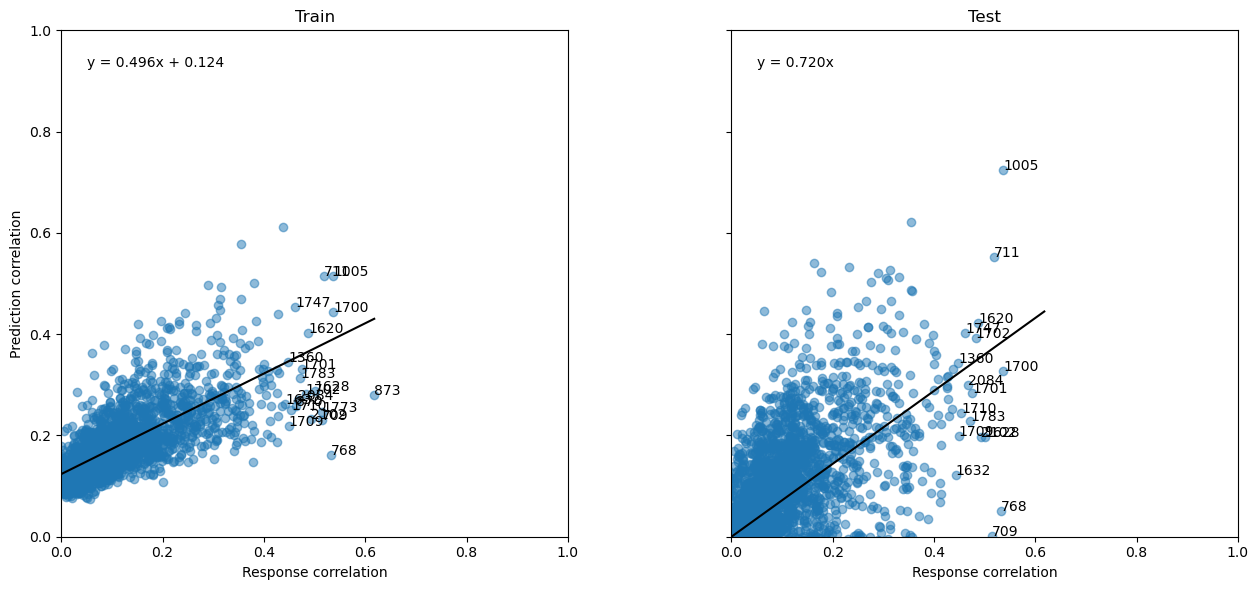

train fit: y = 0.496133 x + 0.123879
test fit : y = 0.720030 x


In [29]:
# plot neuron prediction correlation.

fig, axes = plt.subplots( 1, 2,  figsize=(14, 6),  sharex=True,  sharey=True )

# ---------- left: r_train ----------
ax = axes[0]
ax.scatter(respcorr, r_train, alpha=0.5)

for i in largest_respcorr_indices:
    ax.annotate(f"{i}", (respcorr[i], r_train[i]))

mask = np.isfinite(respcorr) & np.isfinite(r_train)
a_train, b_train = np.polyfit(respcorr[mask], r_train[mask], 1)
xx = np.linspace(np.nanmin(respcorr), np.nanmax(respcorr), 200)
ax.plot(xx, a_train * xx + b_train, color='black')

ax.text( 0.05, 0.95, f"y = {a_train:.3f}x + {b_train:.3f}",  transform=ax.transAxes,  va="top")

ax.set_title("Train")
ax.set_xlabel("Response correlation")
ax.set_ylabel("Prediction correlation")
ax.set_aspect('equal', adjustable='box')
ax.set_ylim(0, 1)
ax.set_xlim(0, 1)

# ---------- right: r_test ----------
ax = axes[1]
ax.scatter(respcorr, r_test, alpha=0.5)

for i in largest_respcorr_indices:
    ax.annotate(f"{i}", (respcorr[i], r_test[i]))

mask = np.isfinite(respcorr) & np.isfinite(r_test)

# constrained through origin
a_test = np.sum(respcorr[mask] * r_test[mask]) / np.sum(respcorr[mask] ** 2)
ax.plot(xx, a_test * xx, color='black')

ax.text(0.05, 0.95, f"y = {a_test:.3f}x", transform=ax.transAxes,  va="top")

ax.set_title("Test")
ax.set_xlabel("Response correlation")
ax.set_aspect('equal', adjustable='box')


plt.tight_layout()
plt.savefig(output_folder / 'respcorr_vs_prediction_correlation_5.png', dpi=300)
plt.show()

print(f"train fit: y = {a_train:.6f} x + {b_train:.6f}")
print(f"test fit : y = {a_test:.6f} x")


## Reliability estimates

In [30]:
# Split-half reliability variant for normalized test correlation.
# Here respcorr is treated as CChalf, then converted to CCmax.
from analysis_utils import ccmax_from_cchalf_simple, ccmax_schoppe_from_trials

CCmax = ccmax_from_cchalf_simple(respcorr)

CCmax_schoppe = ccmax_schoppe_from_trials(spks)

Median CCmax from split-half reliability (on accepted cells): 0.573
Median CCmax from Schoppe method (on accepted cells): 0.575


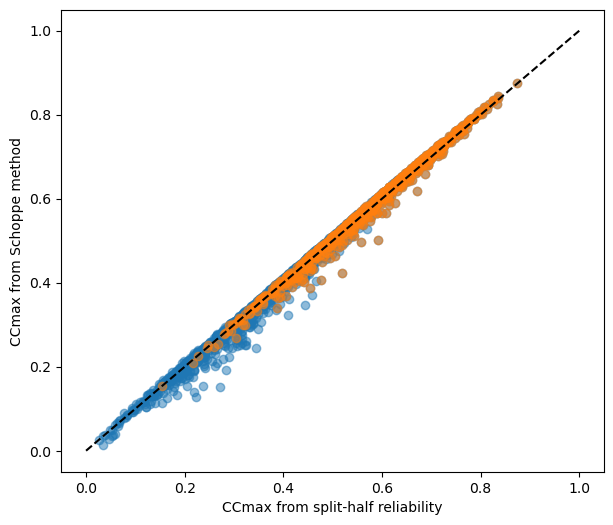

In [31]:
fig, ax = plt.subplots(figsize=(7, 6))
#ax.scatter(respcorr, CCmax, alpha=0.5)
ax.scatter(CCmax, CCmax_schoppe, alpha=0.5)
ax.scatter(CCmax[accepted_mask], CCmax_schoppe[accepted_mask], alpha=0.5)
ax.plot([0, 1], [0, 1], color="black", linestyle="--")
ax.set_xlabel("CCmax from split-half reliability")
ax.set_ylabel("CCmax from Schoppe method")

print(f"Median CCmax from split-half reliability (on accepted cells): {np.nanmedian(CCmax[accepted_mask]):.3f}")
print(f"Median CCmax from Schoppe method (on accepted cells): {np.nanmedian(CCmax_schoppe[accepted_mask]):.3f}")

Population-level approximate CCnorm: 0.254
Median cellwise CCnorm (accepted only): 0.268


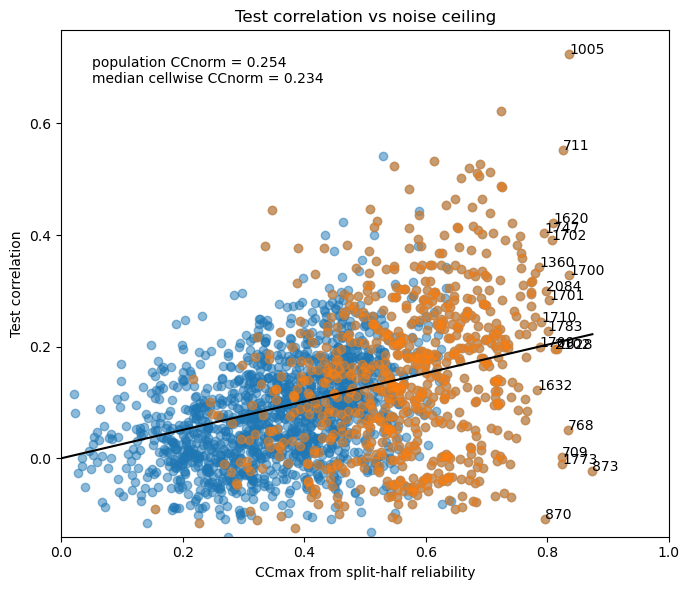

In [32]:


CCnorm = np.full_like(r_test, np.nan, dtype=float)
valid = np.isfinite(r_test) & np.isfinite(CCmax) & (CCmax > 0)
CCnorm[valid] = r_test[valid] / CCmax[valid]

x = CCmax
y = r_test
valid_fit = np.isfinite(x) & np.isfinite(y) & (x > 0)

test_fit_a_CC = np.nan
if np.any(valid_fit):
    test_fit_a_CC = np.sum(x[valid_fit] * y[valid_fit]) / np.sum(x[valid_fit] ** 2)

print(f"Population-level approximate CCnorm: {test_fit_a_CC:.3f}")
print(f"Median cellwise CCnorm (accepted only): {np.nanmedian(CCnorm[accepted_mask]):.3f}")

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(x[valid_fit], y[valid_fit], alpha=0.5)
ax.scatter(x[valid_fit & accepted_mask], y[valid_fit & accepted_mask], alpha=0.5)

for i in largest_respcorr_indices:
    if np.isfinite(x[i]) and np.isfinite(y[i]):
        ax.annotate(f"{i}", (x[i], y[i]))

if np.any(valid_fit):
    xx = np.linspace(0, np.nanmax(x[valid_fit]), 200)
    ax.plot(xx, test_fit_a_CC * xx, color="black")

ax.set_xlabel("CCmax from split-half reliability")
ax.set_ylabel("Test correlation")
ax.set_title("Test correlation vs noise ceiling")
ax.text(
    0.05,
    0.95,
    f"population CCnorm = {test_fit_a_CC:.3f}\n"
    f"median cellwise CCnorm = {np.nanmedian(CCnorm):.3f}",
    transform=ax.transAxes,
    va="top",
    bbox=dict(facecolor="white", alpha=0.8, edgecolor="none"),
)
ax.set_xlim([0, 1])
ax.set_ylim(bottom=min(0, np.nanmin(y[valid_fit])) if np.any(valid_fit) else 0)

plt.tight_layout()
plt.savefig(output_folder / "ccmax_vs_prediction_correlation.png", dpi=300)
plt.show()


this is comparable to https://pmc.ncbi.nlm.nih.gov/articles/PMC11981942/#Fig3 (Wang 2025) left side of the curves.

## Save results

In [33]:
stat['train_fit_a'] = a_train
stat['train_fit_b'] = b_train
stat['test_fit_a'] = a_test
metadata['stat'] = stat

In [34]:
#save results into cell database

df_cells["RF_indexes"] = pd.Series([None] * len(df_cells), dtype="object")
df_cells["WL_transient_mod"] = pd.Series([None] * len(df_cells), dtype="object")

df_cells["Cell_activity"] = pd.Series([None] * len(df_cells), dtype="object")
df_cells["tun_xs"] = pd.Series([None] * len(df_cells), dtype="object")
df_cells["tun_ys"] = pd.Series([None] * len(df_cells), dtype="object")
df_cells["tun_xy"] = pd.Series([None] * len(df_cells), dtype="object")
df_cells["tun_angles"] = pd.Series([None] * len(df_cells), dtype="object")
df_cells["tun_sizes"] = pd.Series([None] * len(df_cells), dtype="object")
df_cells["tun_freqs"] = pd.Series([None] * len(df_cells), dtype="object")
df_cells["tun_xs_params"] = pd.Series([None] * len(df_cells), dtype="object")
df_cells["tun_ys_params"] = pd.Series([None] * len(df_cells), dtype="object")
df_cells["tun_sizes_params"] = pd.Series([None] * len(df_cells), dtype="object")
df_cells["tun_freqs_params"] = pd.Series([None] * len(df_cells), dtype="object")
df_cells["tun_drifts_params"] = pd.Series([None] * len(df_cells), dtype="object")
if feature_dim_number>6:
    df_cells["tun_phases"] = pd.Series([None] * len(df_cells), dtype="object")


for _idx in tqdm(range(n_neurons)):
    df_cells.loc[_idx,'Repeatability'] = respcorr[_idx]
    
    max_idx = max_idxs[_idx] # use pre-stored max idx for consistency with interactive view
    
    df_cells.at[_idx, 'RF_indexes'] = [int(ij) for ij in max_idx] # store the RF index of the best RF for each neuron as a list
    df_cells.loc[_idx, 'r_train'] = r_train[_idx]
    df_cells.loc[_idx, 'r_test'] = r_test[_idx]
    
    df_cells.loc[_idx, 'Azimuth'] = xs[max_idx[0]]
    df_cells.loc[_idx, 'Elevation'] = ys[max_idx[1]]
    df_cells.loc[_idx, 'Angle'] = angles[max_idx[2]]
    df_cells.loc[_idx, 'Size'] = sizes[max_idx[3]]
    df_cells.loc[_idx, 'Frequency'] = freqs[max_idx[4]]
    if feature_dim_number>5:
        df_cells.loc[_idx, 'Phase'] = phases[max_idx[5]]


    transient_mod = dwt[:, *max_idx]
    
    df_cells.at[_idx, 'WL_transient_mod'] = transient_mod
    df_cells.at[_idx, 'Cell_activity'] = spks[:, :, _idx]
    
    #store tuning curves
    myrfs = rfs[_idx]
    df_cells.at[_idx, 'tun_xs'] = myrfs[:, *max_idx[1:feature_dim_number]]
    df_cells.at[_idx, 'tun_ys'] = myrfs[max_idx[0], :, *max_idx[2:feature_dim_number]]
    df_cells.at[_idx, 'tun_xy'] = myrfs[:, :, *max_idx[2:feature_dim_number]]
            
    df_cells.at[_idx, 'tun_angles'] = myrfs[max_idx[0], max_idx[1], :, *max_idx[3:feature_dim_number]]
    df_cells.at[_idx, 'tun_sizes'] = myrfs[max_idx[0], max_idx[1], max_idx[2], :, *max_idx[4:feature_dim_number]]
    df_cells.at[_idx, 'tun_freqs'] = myrfs[max_idx[0], max_idx[1], max_idx[2], max_idx[3], :, *max_idx[5:feature_dim_number]]
    if feature_dim_number>5:
        df_cells.at[_idx, 'tun_phases'] = myrfs[max_idx[0], max_idx[1], max_idx[2], max_idx[3], max_idx[4], max_idx[5], :]

        
    #store angle fit
    sin_params = tuning_angles_fit[_idx]
    df_cells.loc[_idx, 'Angle_fit_ori'] = sin_params['orientation']
    df_cells.loc[_idx, 'Angle_fit_amplitude'] = sin_params['amplitude']
    df_cells.loc[_idx, 'Angle_fit_constant'] = sin_params['constant']
    df_cells.loc[_idx, 'Angle_fit_OSI'] = sin_params['amplitude'] / (sin_params['amplitude'] + sin_params['constant'])

    df_cells.loc[_idx, 'Azimuth_fit'] = tuning_xs_fit[_idx][0] #best value scalar
    df_cells.loc[_idx, 'Elevation_fit'] = tuning_ys_fit[_idx][0]
    df_cells.loc[_idx, 'Size_fit'] = tuning_sizes_fit[_idx][0]
    df_cells.loc[_idx, 'Frequency_fit'] = tuning_freqs_fit[_idx][0]
    df_cells.at[_idx, 'tun_xs_params'] = tuning_xs_fit[_idx][1] # store fit parametes (tuple)
    df_cells.at[_idx, 'tun_ys_params'] = tuning_ys_fit[_idx][1]
    df_cells.at[_idx, 'tun_sizes_params'] = tuning_sizes_fit[_idx][1]
    df_cells.at[_idx, 'tun_freqs_params'] = tuning_freqs_fit[_idx][1]

picles_path=output_folder / "cells_waven1.cellDB_pickle"

with open(picles_path, 'wb') as f:
    pickle.dump(df_cells, f)
    pickle.dump(metadata, f)  # Save the metadata dictionary as a second object in the same pickle file

# Saving cell database to xls file. Omitting complicated data
df_cells.drop(columns=['WL_transient_mod', 'WL_transient_phase', 'Cell_activity', 'contour', 
                       'tun_xs', 'tun_ys', 'tun_xy', 'tun_angles', 'tun_sizes', 'tun_freqs', 'tun_drifts','tun_phases',
                       'tun_xs_params', 'tun_ys_params',  'tun_sizes_params', 'tun_freqs_params', 'tun_drifts_params'], inplace=True, errors='ignore')
df_cells.to_excel(output_folder / "cells_waven1.xlsx", index=False)

print(f"Saved cell database to {picles_path}")


100%|██████████| 2163/2163 [00:02<00:00, 965.89it/s]


Saved cell database to D:\SynologyDriveSyncedDATA\PROCESSED\GBM\GBM11\g11_0730_zebraO\ZEBRA_ANALYSIS\gaborLibrary_20_11_16_7_7_2.e5f712b8_complex\cells_waven1.cellDB_pickle


In [35]:
print(max_idx)
print(rfs.shape)

[8 7 8 2 1]
(2163, 20, 11, 16, 7, 7)


In [36]:
#save stat to excel file
stat_path = output_folder / "stat.xlsx"
with pd.ExcelWriter(stat_path, engine='openpyxl') as writer:
    pd.DataFrame([stat]).to_excel(writer, index=False, sheet_name='stat')

In [37]:
print(jobFolder_str)
print(output_folder)

GBM11\g11_0730_zebraO
D:\SynologyDriveSyncedDATA\PROCESSED\GBM\GBM11\g11_0730_zebraO\ZEBRA_ANALYSIS\gaborLibrary_20_11_16_7_7_2.e5f712b8_complex


## Interactive visualization

In [38]:
#load downsampled video
downsampled_video=np.load(downsampled_video_path)

if downsampled_video.shape[0] != dwt.shape[0]:
    raise ValueError("downsampled_video and dwt must have the same number of frames")

In [39]:
#interactive plot
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

zoomwidth = 30 # 30hz resampling

az_left, az_right, el_bottom, el_top = visual_coverage


param_names = ["x", "y", "angle", "size", "freq", "drift"]
param_values = [xs, ys, angles, sizes, freqs]
if feature_dim_number>6:
    param_names.append("phase")
    param_values.append(phases)
    
response_matrix = np.asarray(mean_spks)

n_frames = min(downsampled_video.shape[0], dwt.shape[0], response_matrix.shape[0])
n_neurons = response_matrix.shape[1]

slider_width = "300px"

sliders = [
    widgets.IntSlider(
        value=len(vals) // 2,
        min=0,
        max=len(vals) - 1,
        step=1,
        description=name,
        continuous_update=False,
        layout=widgets.Layout(width=slider_width)
    )
    for name, vals in zip(param_names, param_values)
]

neuron_box = widgets.BoundedIntText(
    value=0,
    min=0,
    max=n_neurons - 1,
    step=1,
    description="neuron",
    layout=widgets.Layout(width="280px")
)

time_slider = widgets.IntSlider(
    value=0,
    min=0,
    max=n_frames - 1,
    step=1,
    description="frame",
    continuous_update=False,
    layout=widgets.Layout(width="100%")
)

time_box = widgets.BoundedIntText(
    value=0,
    min=0,
    max=n_frames - 1,
    step=1,
    description="frame",
    layout=widgets.Layout(width=slider_width)
)

time_next= widgets.Button(description="Next action", layout=widgets.Layout(width="150px"))

out_rfs = widgets.Output()
out_time = widgets.Output()
out_overlay = widgets.Output()

_updating_time = False
_updating_neuron = False


def set_sliders_to_neuron_max(my_neuron):
    myrfs = rfs[my_neuron]
    max_idx = np.unravel_index(np.argmax(myrfs), myrfs.shape)
    max_idx = tuple(int(i) for i in max_idx)
    max_value = myrfs[max_idx]

    print(
        f"Neuron {my_neuron} max RF value: {max_value:.3f} "
        f"at index {max_idx}, respcorr: {respcorr[my_neuron]:.3f}"
    )

    for s, idx in zip(sliders, max_idx):
        s.value = idx


def plot_view(*args):
    if feature_dim_number>6:
        xi, yi, anglei, sizei, freqi,  phasei = [s.value for s in sliders]
    else:
        xi, yi, anglei, sizei, freqi = [s.value for s in sliders]
        phasei = 0
        
    ti = time_slider.value
    ni = neuron_box.value

    frame = downsampled_video[ti]
    filt = get_filter_from_params(xi, yi, anglei, sizei, freqi,  phasei, wavelet_params)

    if feature_dim_number>6:
        transient = dwt[:n_frames, xi, yi, anglei, sizei, freqi,  phasei]
    else:
        transient = dwt[:n_frames, xi, yi, anglei, sizei, freqi]
    neuron_trace = response_matrix[:n_frames, ni]

    if feature_dim_number>6:
        current_rfs = rfs[ni, xi, yi, anglei, sizei, freqi,  phasei]
    else:
        current_rfs = rfs[ni, xi, yi, anglei, sizei, freqi]
    current_respcorr = respcorr[ni]

    title_params = (
        f"frame={ti}, neuron={ni}, respcorr={current_respcorr:.4f}, "
        f"rfs={current_rfs:.4f}\n"
        f"x={xs[xi]:.2f}, y={ys[yi]:.2f}, "
        f"angle={angles[anglei]:.2f}, "
        f"size={sizes[sizei]:.2f}, "
        f"freq={freqs[freqi]:.3f}, "
        f"phase={phases[phasei]:.2f}"
    )

    with out_rfs:
        out_rfs.clear_output(wait=True)

        fig, axes = plt.subplots(2, 3, figsize=(11, 5))
        axes = axes.flat

        if feature_dim_number>5:
            cross_sections = [
                ("x", xs, rfs[ni, :, yi, anglei, sizei, freqi,  phasei], xi),
                ("y", ys, rfs[ni, xi, :, anglei, sizei, freqi,  phasei], yi),
                ("angle", angles, rfs[ni, xi, yi, :, sizei, freqi,  phasei], anglei),
                ("size", sizes, rfs[ni, xi, yi, anglei, :, freqi,  phasei], sizei),
                ("freq", freqs, rfs[ni, xi, yi, anglei, sizei, :,  phasei], freqi),
                ("phase", phases, rfs[ni, xi, yi, anglei, sizei, freqi,  :], phasei),
            ]
        else:
            cross_sections = [
                ("x", xs, rfs[ni, :, yi, anglei, sizei, freqi], xi),
                ("y", ys, rfs[ni, xi, :, anglei, sizei, freqi], yi),
                ("angle", angles, rfs[ni, xi, yi, :, sizei, freqi], anglei),
                ("size", sizes, rfs[ni, xi, yi, anglei, :, freqi], sizei),
                ("freq", freqs, rfs[ni, xi, yi, anglei, sizei, :], freqi),
            ]

        for ax, (name, vals, data, idx) in zip(axes, cross_sections):
            ax.plot(vals, data, marker="o")
            ax.axvline(vals[idx], color="red", linestyle="--", linewidth=1.5)
            ax.axhline(0, color="black", linewidth=0.5)
            ax.set_title(f"{name} | rfs={data[idx]:.4f}", fontsize=9)
            ax.set_xlabel(name)
            ax.set_ylabel("rfs")
            
        #angles plot different
        # interpolated fit
        x_fit = np.linspace(0, 1*np.pi, 100)
        sin_params = tuning_angles_fit[ni]
        y_fit = sine1x(x_fit, **sin_params)
        axes[2].plot(x_fit, y_fit, marker="none", color="gray", linewidth=0.5)
        axes[2].axvline(sin_params['orientation'], color="gray", linewidth=0.5)
        axes[2].axhline(sin_params['constant'], linestyle="--", linewidth=0.5, color="gray")
        axes[2].set_title(f"angle | orientation={np.rad2deg(sin_params['orientation']):.1f}°", fontsize=9)

        fig.suptitle(f"RFS cross-sections — neuron {ni}", fontsize=11)
        plt.tight_layout()
        plt.show()

    with out_time:
        out_time.clear_output(wait=True)

        z0 = max(0, ti - zoomwidth)
        z1 = min(n_frames, ti + zoomwidth+1)
        t_zoom = np.arange(z0, z1)

        fig, (ax_zoom, ax_full) = plt.subplots(
            1, 2,
            figsize=(14, 3.5),
            gridspec_kw={"width_ratios": [1, 2]}
        )

        ax_full.plot(np.arange(n_frames), transient)
        ax_full.axvline(ti, color="red", linestyle="--", linewidth=2)
        ax_full.set_xlim(0, n_frames - 1)
        ax_full.set_xlabel("Frame")
        ax_full.set_title(
            f"WT + neuron transient — full | neuron={ni}, respcorr={current_respcorr:.4f}"
        )

        ax_full_r = ax_full.twinx()
        ax_full_r.plot(np.arange(n_frames), neuron_trace, color="orange", alpha=0.8)
        ax_full_r.set_ylabel("Neuron response")

        wt_ylim = ax_full.get_ylim()
        neuron_ylim = ax_full_r.get_ylim()

        ax_zoom.plot(t_zoom, transient[z0:z1], marker="o")
        ax_zoom.axvline(ti, color="red", linestyle="--", linewidth=2)
        ax_zoom.set_xlim(z0, z1 - 1)
        ax_zoom.set_ylim(wt_ylim)
        ax_zoom.set_title(f"Zoom ±{zoomwidth} frames")
        ax_zoom.set_xlabel("Frame")
        ax_zoom.set_ylabel("WT response")

        ax_zoom_r = ax_zoom.twinx()
        ax_zoom_r.plot(t_zoom, neuron_trace[z0:z1], color="orange", marker=".")
        ax_zoom_r.set_ylim(neuron_ylim)

        ax_zoom_r.set_yticks([])
        ax_zoom_r.set_ylabel("")
        ax_zoom_r.spines["right"].set_visible(False)

        ax_full.set_yticks([])
        ax_full.set_ylabel("")
        ax_full.spines["left"].set_visible(False)

        plt.tight_layout()
        plt.show()

    with out_overlay:
        out_overlay.clear_output(wait=True)

        fig, (ax, ax_sta) = plt.subplots(1, 2, figsize=(10, 4))

        ax.imshow(
            frame.T,
            cmap="gray",
            extent=[az_left, az_right, el_bottom, el_top],
            origin="lower",
            aspect="equal",
        )

        filt_plot = filt.T
        v = np.max(np.abs(filt_plot))
        if v == 0:
            v = 1

        rgba = np.zeros((*filt_plot.shape, 4), dtype=float)
        pos = filt_plot > 0
        neg = filt_plot < 0

        rgba[neg, 0] = 1.0
        rgba[pos, 1] = 1.0
        rgba[..., 3] = np.abs(filt_plot) / v * 0.7

        ax.imshow(
            rgba,
            extent=[az_left, az_right, el_bottom, el_top],
            origin="lower",
            aspect="auto",
        )

        ax.set_title("Video + selected Gabor overlay\n" + title_params)
        ax.set_xlabel("Azimuth (°)")
        ax.set_ylabel("Elevation (°)")
        
        #ax_sta.imshow(sta[ni].T, extent=[az_left, az_right, el_bottom, el_top],
        #    origin="lower",
        #    aspect="auto",)
        ax_sta.set_title(f"???", fontsize=9)
        ax_sta.axvline(xs[xi], color="gray",  linewidth=1)
        ax_sta.axhline(ys[yi], color="gray",  linewidth=1)
        ax_sta.set_xlabel("Azimuth (°)")
        ax_sta.set_ylabel("Elevation (°)")

        plt.tight_layout()
        plt.show()


def sync_time_from_slider(change):
    global _updating_time
    if _updating_time:
        return
    _updating_time = True
    time_box.value = change["new"]
    _updating_time = False
    plot_view()


def sync_time_from_box(change):
    global _updating_time
    if _updating_time:
        return
    _updating_time = True
    time_slider.value = change["new"]
    _updating_time = False
    plot_view()


def update_neuron(change=None):
    global _updating_neuron
    if _updating_neuron:
        return

    _updating_neuron = True
    set_sliders_to_neuron_max(neuron_box.value)
    _updating_neuron = False

    plot_view()


def on_next_action(button):
    # Jump to the next time point where the neuron response is above threshold.
    current_time = time_slider.value
    neuron_trace = response_matrix[:n_frames, neuron_box.value]

    threshold = np.nanmax(neuron_trace) * 0.5

    # Start from current_time + 1, otherwise it can keep finding the current frame.
    search_start = min(current_time + 1, n_frames - 1)

    above_threshold_indices = np.where(neuron_trace[search_start:] > threshold)[0]

    if len(above_threshold_indices) > 0:
        next_time = search_start + int(above_threshold_indices[0])
        time_slider.value = next_time

        # If value did not actually change for some reason, force redraw.
        if next_time == current_time:
            plot_view()

 

for s in sliders:
    s.observe(plot_view, names="value")

time_slider.observe(sync_time_from_slider, names="value")
time_box.observe(sync_time_from_box, names="value")
neuron_box.observe(update_neuron, names="value")
time_next.on_click(on_next_action)

slider_box = widgets.VBox([neuron_box] + sliders)
top_row = widgets.HBox([slider_box, out_rfs])
time_control = widgets.HBox([time_box, time_next, time_slider])

display(top_row, out_time, time_control, out_overlay)

update_neuron()

Output()

Output()

Neuron 0 max RF value: 0.189 at index (7, 6, 3, 3, 1), respcorr: 0.123


C:\Users\KatonaGergely\AppData\Local\Temp\ipykernel_49552\2615212939.py:29: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax[1].scatter(stim1, resp, alpha=0.5,  cmap="jet")


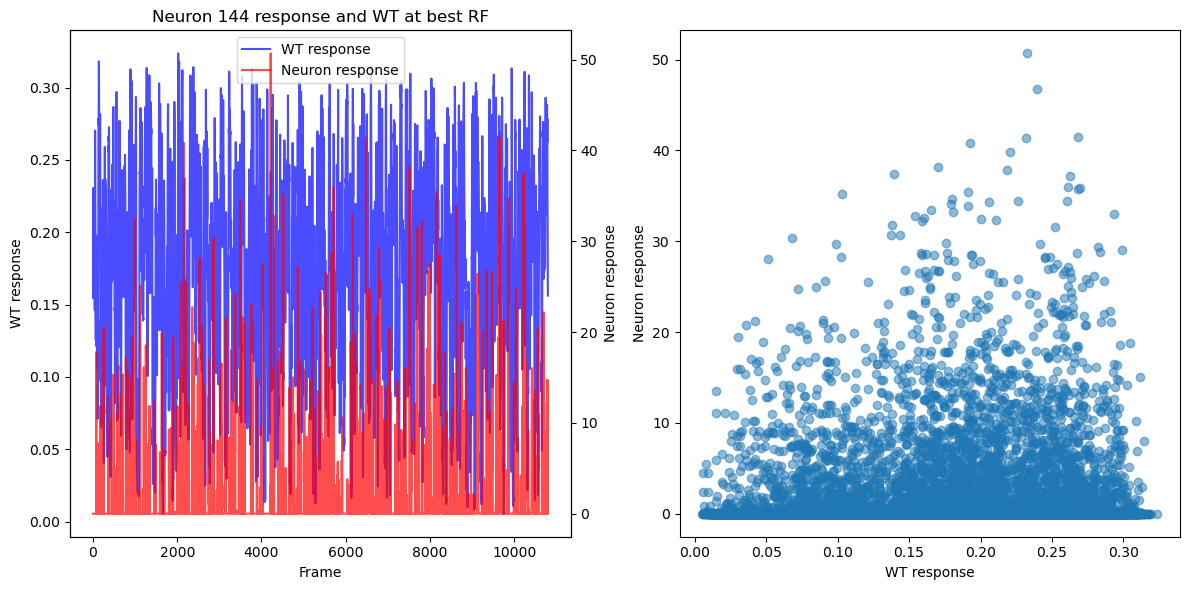

In [40]:
#play response display
ni=144
resp=mean_spks[:, ni]

stim1=dwt[:, *max_idxs[ni]]

fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# first subplot with two y axes
ax0 = ax[0]
ax0b = ax0.twinx()

l1 = ax0.plot(stim1, label="WT response", color="blue", alpha=0.7)
l2 = ax0b.plot(resp, label="Neuron response", color="red", alpha=0.7)

ax0.set_title(f"Neuron {ni} response and WT at best RF")
ax0.set_xlabel("Frame")
ax0.set_ylabel("WT response")
ax0b.set_ylabel("Neuron response")

# combined legend
lines = l1 + l2
labels = [line.get_label() for line in lines]
ax0.legend(lines, labels, loc="best")

# second subplot
#ax[1].scatter(stim1, resp, alpha=0.5, c=np.log(energy), cmap="jet")
#ax[1].scatter(stim1, resp, alpha=0.5, c=flow_speed_perp, cmap="jet")
ax[1].scatter(stim1, resp, alpha=0.5,  cmap="jet")
ax[1].set_xlabel("WT response")
ax[1].set_ylabel("Neuron response")

plt.tight_layout()
plt.show()

## Storing metadata

In [41]:
#safe readable yaml exporter to export dicts
import yaml
import numpy as np
from pathlib import Path
from collections.abc import Mapping, Sequence

_SKIP = object()


def make_yaml_readable(obj, *, max_array_items=200, skip_unknown=True):
    """
    Convert nested dict/list metadata to YAML-safe, human-readable objects.
    Not intended for exact loading back.
    """

    # --- NumPy scalars FIRST ---
    if isinstance(obj, np.generic):
        obj = obj.item()

        if isinstance(obj, float):
            if np.isnan(obj):
                return "nan"
            if np.isposinf(obj):
                return "inf"
            if np.isneginf(obj):
                return "-inf"

        return obj

    # --- Basic Python types ---
    if obj is None or isinstance(obj, (str, int, float, bool)):
        if isinstance(obj, float):
            if np.isnan(obj):
                return "nan"
            if np.isposinf(obj):
                return "inf"
            if np.isneginf(obj):
                return "-inf"
        return obj

    # pathlib
    if isinstance(obj, Path):
        return str(obj)

    # NumPy arrays
    if isinstance(obj, np.ndarray):
        if obj.size <= max_array_items:
            return make_yaml_readable(obj.tolist(), max_array_items=max_array_items)

        summary = {
            "type": "numpy.ndarray",
            "shape": list(obj.shape),
            "dtype": str(obj.dtype),
        }

        if np.issubdtype(obj.dtype, np.number):
            finite = obj[np.isfinite(obj)]
            if finite.size:
                summary.update({
                    "min": float(np.nanmin(finite)),
                    "max": float(np.nanmax(finite)),
                    "mean": float(np.nanmean(finite)),
                })

        return summary

    # Dicts
    if isinstance(obj, Mapping):
        out = {}
        for k, v in obj.items():
            safe_key = make_yaml_readable(k, max_array_items=max_array_items, skip_unknown=skip_unknown)

            if safe_key is _SKIP:
                continue

            if not isinstance(safe_key, (str, int, float, bool)):
                safe_key = str(safe_key)

            safe_val = make_yaml_readable(v, max_array_items=max_array_items, skip_unknown=skip_unknown)

            if safe_val is not _SKIP:
                out[safe_key] = safe_val

        return out

    # Lists / tuples
    if isinstance(obj, Sequence) and not isinstance(obj, (str, bytes, bytearray)):
        out = []
        for item in obj:
            safe_item = make_yaml_readable(item, max_array_items=max_array_items, skip_unknown=skip_unknown)
            if safe_item is not _SKIP:
                out.append(safe_item)
        return out

    # Unknown objects
    if skip_unknown:
        return _SKIP

    return str(obj)


def save_yaml_readable(params, filename="params.yaml", *, max_array_items=200):
    safe_params = make_yaml_readable(params, max_array_items=max_array_items)

    with open(filename, "w", encoding="utf-8") as f:
        yaml.safe_dump(
            safe_params,
            f,
            sort_keys=False,
            allow_unicode=True,
            default_flow_style=False,
            width=120,
        )

In [42]:
#save metadata to human readable file
meta_path_path=output_folder / "metadata_humanreadable.yaml"

save_yaml_readable(metadata, filename=meta_path_path)

In [43]:
#print metadata
pmetadata=metadata.copy()
pmetadata["cnm_params"]=0
pmetadata

{'jobFolder': 'D:\\SynologyDriveSyncedDATA\\PROCESSED\\GBM\\GBM11\\g11_0730_zebraO',
 'hdf5_file': 'D:\\SynologyDriveSyncedDATA\\PROCESSED\\GBM\\GBM11\\g11_0730_zebraO\\CAIMAN\\g11_0730_zebraO_cnmf.hdf5',
 'extractor_log': {'SeriesID': 'g11_0730_zebraO',
  'extract_image_channel': 'UG',
  'extracted_data_dimension': [11369, 512, 512],
  'extraction_date': '2026-07-31 13:41:34.573483',
  'extractor_yamlname': 'g11_0730_zebraO.extractor_yaml',
  'last_sourcefile': 'D:\\SynologyDriveSyncedDATA\\RAW\\GBM_TTK\\GBM11\\20260730_sorozat.mesc',
  'source_measurement_unit_numbers': [4, 5, 6, 7],
  'targetdirectory': 'Y:\\GBM\\GBM11\\g11_0730_zebraO',
  'temporal_downsampling': 3},
 'SeriesID': 'g11_0730_zebraO',
 'video_file': 'D:\\SynologyDriveSyncedDATA\\PROCESSED\\Waven\\zebra_s1_d360.0_fps144.00.mp4',
 'resampled_video_file': 'D:\\SynologyDriveSyncedDATA\\PROCESSED\\Waven\\zebra_s0_d360.0_fps144.00_RESAMPLED30fps.mp4',
 'target_fps': 30,
 'PhotodiodeChannel': 'AUXi_1',
 'cnm_params': 0,
 'cn